<a href="https://colab.research.google.com/github/AnaMunozz/Analitica-de-Negocios/blob/main/Parcial_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Parcial 1**
Comparar, para una entidad del sector Salud, tres diferentes modelos para la clasificación de  pacientes que poseen diabetes en función de sus variables de salud. Así, se aplicarán los modelos de Naive Bayes, Árboles de Decisión y Clustering K-Means, evaluando su desempeño mediante la matriz de confusión y las métricas derivadas.


Para esto, se dispone de la siguiente base de datos: Pima Indians Diabetes Database disponible en Kaggle (https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database) o "diabetes.csv"

En este sentido, las variables de salud que posee la base de datos son:
* **Pregnancies** o **Embarazos:** Número de veces que la persona ha tenido un embarazo. Es un número entero (variable cuantitativa discreta).
* **Glucose** o **Glucosa:** Concentración de glucosa en sangre medida a las 2 horas durante una prueba de tolerancia oral a la glucosa. Es una variable cuantitativa continua.
* **BloodPressure** o **Presión sanguínea:** Presión arterial diastólica (en reposo) medida en milímetros de mercurio (mm Hg). Es una variable cuantitativa continua.
* **SkinThickness** o **GrosorPiel:** Grosor del pliegue de la piel del tríceps medido en milímetros (mm). Es una variable cuantitativa continua.
* **Insulin** o **Insulina:** Concentración de insulina en suero medida a las 2 horas durante una prueba de tolerancia oral a la glucosa. Es una variable cuantitativa continua.
* **BMI** o **IMC:** Índice que relaciona el peso corporal con la estatura. Es una variable cuantitativa continua.
* **DiabetesPedigreeFunction** o **Antecedentes:** Resume la predisposición genética a la diabetes considerando antecedentes familiares. Es una variable cuantitativa continua.
* **Age** o **Edad:** Edad del paciente al momento de tomar los datos. Es una variable cuantitativa discreta
* **Outcome:** Variable objetivo que indica la presencia o ausencia de diabetes (Variable categórica binaria; 0 o 1)

##**0. Carga de librerías**
Se procede con la carga de las librerías de trabajo

In [ ]:
import numpy as np               #Librería numérica por excelencia
import pandas as pd              #Librería para el manejo de bases de datos
import matplotlib.pyplot as plt  #Librería para gráficar
import seaborn as sns            #Herramienta para realizar gráficas estadísticas

#Librerías específicas
from sklearn.naive_bayes import GaussianNB      # Modelo Naive Bayes
from sklearn.tree import DecisionTreeClassifier # Árbol de Decisión
from sklearn.cluster import KMeans              #Clustering K-Means
from sklearn.metrics import confusion_matrix    ## Para evaluar si los datos se clasificaron de manera adecuada

import warnings
warnings.filterwarnings("ignore", category = UserWarning)

##**1. Carga de datos**
Se cargan los datos de trabajo del archivo "diabetes.csv"

In [ ]:
nxl = '/content/diabetes.csv'
XDB = pd.read_csv(nxl)

# Definición de variables
XD = XDB.iloc[:,[0,1,2,3,4,5,6,7]]  #Variables predictoras
yd = XDB.iloc[:,8]          #Variable de salida / decisión

## **2. Análisis Exploratorio**
Se explora el dataset identificando el número de observaciones, variables y tipos de datos como parte inicial.

In [ ]:
print("Columnas y tipos de datos de la base de datos:")
XDB.info()                            # Muestra las columnas, cuenta de datos no nulos y tipo
print("\nEstadísticas descriptivas para las columnas numéricas:")
print(XDB.describe())                              # Información estadística básica
print("\nVista prelimiar de 5 filas:")
XDB.head()                                         # Muestra las primeras 5 líneas para imspección rápida

Columnas y tipos de datos de la base de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Estadísticas descriptivas para las columnas numéricas:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


##**3. Modelo de Naive Bayes**

Entrenar un modelo de Naive Bayes, identificando los limites superiores e inferiores para cada una de las variables. Es importante por clasificación de diabetes, cual grupo posee mayores o menores valores frente a las variables de entrada.

###**3.1. Implementación del Modelo**

In [ ]:
mnb = GaussianNB()
mnb.fit(XD, yd) # Ajustar variables Entrada-Salida

# Mostrar las medias de las variables
u = mnb.theta_
sigma = mnb.var_
print('Embarazos', 'Glucosa','PresiónSanguínea',"GrosorPiel", "Isulina", 'IMC',"Antecedentes", 'Edad')
print(u)
print("\nLas desviaciones son: ")
print(sigma)

#Límites inferiores y superiores ------------------
desv = np.sqrt(sigma)

lim_inf = u - desv
lim_sup = u + desv

print("\nLímites inferiores")
print(lim_inf)

print("\nLímites superiores")
print(lim_sup)

Embarazos Glucosa PresiónSanguínea GrosorPiel Isulina IMC Antecedentes Edad
[[  3.298      109.98        68.184       19.664       68.792
   30.3042       0.429734    31.19      ]
 [  4.86567164 141.25746269  70.82462687  22.1641791  100.3358209
   35.14253731   0.5505      37.06716418]]

Las desviaciones son: 
[[9.08520926e+00 6.81995613e+02 3.25622157e+02 2.21267117e+02
  9.75479675e+03 5.90156156e+01 8.92863791e-02 1.35861913e+02]
 [1.39446557e+01 1.01633298e+03 4.60174481e+02 3.11405894e+02
  1.91629022e+04 5.25538755e+01 1.38143783e-01 1.19853711e+02]]

Límites inferiores
[[  0.28383191  83.86495427  50.13899634   4.78894984 -29.97437459
   22.62203783   0.13092574  19.53401813]
 [  1.13141727 109.37748496  49.37294904   4.51748269 -38.0943137
   27.89313213   0.17882301  26.11939221]]

Límites superiores
[[  6.31216809 136.09504573  86.22900366  34.53905016 167.55837459
   37.98636217   0.72854226  42.84598187]
 [  8.59992601 173.13744041  92.27630469  39.81087552 238.76595549
  

### **3.2. Evaluación del modelo | Matriz de Confusión + Métricas de Desempeño**
Se procede con la evaluación del modelo, utilizando la matriz de confusión.

In [ ]:
ydp = mnb.predict(XD) # Predicción realizada por el modelo

#MATRIZ DE CONFUSIÓN -----------------------------------------------------------
cm = confusion_matrix(yd, ydp)
print(cm)

# MÉTRICAS DE DESEMPEÑO --------------------------------------------------------
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]; TDatos=len(XDB)

#1. Exactitud: Funcionamiento general del modelo
Ex = (VP+VN)/TDatos
print("\nExactitud: ", Ex) #A partir del 75% es un buen modelo

#2. Tasa Error: %Fallos del modelo
TEr = (FP+FN)/TDatos
print("Tasa Error: ", TEr)

#3. Sensibilidad: Comportamiento frente a los positivos
Se = VP/(VP+FN)
print("Sensibilidad: ", Se)

#4. Especificidad: Comportamiento frente a los negativos
Es = VN/(VN+FP)
print("Especificidad: ", Es)

#5. Precisión: Versión alternativa del comportamiento frente a los positivos
Pr = VP/(VP+FP)
print("Precisión: ", Pr)

#6. Predicción negativa: comportamiento frente a los casos negativos
PrN = VN/(VN+FN)
print("Predicción Negativa: ", PrN)

[[421  79]
 [103 165]]

Exactitud:  0.7630208333333334
Tasa Error:  0.23697916666666666
Sensibilidad:  0.6156716417910447
Especificidad:  0.842
Precisión:  0.6762295081967213
Predicción Negativa:  0.8034351145038168


###**Naive Bayes - Análisis de Resultados**
* **Límites, Medias y Desviaciones**

En primer lugar, se evidencia que los individuos con diabetes presentan en promedio mayores niveles de **glucosa**, alcanzando un valor medio cercano a *141.26*, mientras que el grupo sin diabetes presenta un promedio cercano a *109.98*.

De igual forma, se observa que el índice de masa corporal (**IMC**) también es mayor en los pacientes con diabetes, con un promedio aproximado de *35.1*, frente a *30.3* en los casos negativos, lo que sugiere una relación entre el sobrepeso u obesidad y el desarrollo de diabetes.

Respecto a la **edad**, los individuos con diabetes son en promedio mayores (aprox. *37* años) que los pacientes sin diabetes (aprox. *31* años), lo que sugiere que el riesgo de desarrollar la enfermedad tiende a aumentar con el paso del tiempo. Además, el número de **embarazos** también es un poco superior en los casos positivos.

Adicionalmente, se observa que variables como **insulina** y **grosor de piel** presentan valores promedio superiores en el grupo de pacientes con diabetes. También, los pacientes con diabetes presentan mayores valores en **presión sanguínea** y **antecedentes familiares**, lo cual puede estar asociado a factores genéticos relacionados con la enfermedad.

Finalmente, al observar las desviaciones y los límites inferiores y superiores, se evidencia que el grupo de pacientes con diabetes presenta mayor variabilidad en variables como glucosa, número de embarazos e insulina.

* **Métricas de Desempeño**

Sobre el desempeño del modelo de Naive Bayes en la clasificación de pacientes con diabetes, se pueden destacar diferentes cosas.

Apartir de una Exatictud del 75%, se considrea que el modelo tiene un desempeño aceptable. Este modelo alcanza una **Exactitud** de *76,3%*, lo que es solo ligeramente mayor a lo mínimo indicado. En consecuencia, la **Tasa de error** del *23,7%* muestra que existe una proporción de clasificaciones incorrectas.

Por otro lado, el modelo presenta una **Especificidad** de *84,2%*, lo que evidencia una buena capacidad para identificar correctamente a los pacientes que no presentan diabetes. En cuanto a la **Sensibilidad** (*61,6%*), se observa que el modelo logra identficar correctamente poco más de la mitad de los pacientes que realmente presentan diabetes. Esto sugiere la presencia pacientes con diabetes que el modelo clasifica como sanos, lo cual representa una limitación improtante.


En conjunto, estos resultados evidencian que el modelo de Naive Bayes presenta un desempeño aceptable como herramienta de apoyo. Sin embargo, dado que la sensibilidad no es particularmente alta, se recomienda que el modelo sea utilizado con precaución, acompañado de evaluaciones médicas adicionales y de otros modelos de clasificación que permtian mejorar la detección de pacientes con la enfermedad.

###**3.3. Ingreso de Nuevo Paciente**
De acuerdo con las variables que definen el siguiente paciente, se indican los resultados que arroja el modelo frente a la presencia de diabetes: XDp=[2,85,65,29,94,39.6,0.93,27]


In [ ]:
NB_XDp=[2,85,65,29,94,39.6,0.93,27]

ydc = mnb.predict([NB_XDp])
print(ydc)

if ydc == 1:
  print("El paciente presenta diabetes")
else:
  print("El paciente no presenta diabetes")

[0]
El paciente no presenta diabetes


##**4. Árbol de Decisión**
Construir un árbol de decisión (4 niveles), y desplegar las reglas que componen el árbol para la clasificación de los pacientes por nivel de diabetes. Es importante para el análisis identificar el número de nodos puros, y describir para uno de los nodos puros cual posee el mayor número de datos, y cuál es la regla del negocio.

### **4.1. Implementación del Modelo**

In [ ]:
mar = DecisionTreeClassifier(criterion = "gini", max_depth = 4)
mar.fit(XD, yd)  # El modelo busca relación entrada-salida

DecisionTreeClassifier(max_depth=4)

### **4.2. Evaluación del modelo | Matriz de Confusión + Métricas de Desempeño**

In [ ]:
ydp = mar.predict(XD) # Predicción realizada por el modelo

#MATRIZ DE CONFUSIÓN -----------------------------------------------------------
cm = confusion_matrix(yd, ydp)
display(cm)
VN = cm[0,0]; FP = cm[0,1]; FN = cm[1,0]; VP = cm[1,1]

# METRICAS DE DESEMPEÑO --------------------------------------------------------
#1. Exactitud: Funcionamiento general del modelo
Ex = (VP+VN)/len(XD)
print("\nExactitud: ", Ex)

#2. Tasa Error: %Fallos del modelo
TEr = (FP+FN)/len(XD)
print("Tasa Error: ", TEr)

#3. Sensibilidad: Comportamiento frente a los positivos
Se = VP/(VP+FN)
print("Sensibilidad: ", Se)

#4. Especificidad: Comportamiento frente a los negativos
Es = VN/(VN+FP)
print("Especificidad: ", Es)

#5. Precisión: Versión alternativa del comportamiento frente a los positivos
Pr = VP/(VP+FP)
print("Precisión: ", Pr)

#6. Predicción negativa: comportamiento frente a los casos negativos
PrN = VN/(VN+FN)
print("Predicción Negativa: ", PrN)

array([[459,  41],
       [119, 149]])


Exactitud:  0.7916666666666666
Tasa Error:  0.20833333333333334
Sensibilidad:  0.5559701492537313
Especificidad:  0.918
Precisión:  0.7842105263157895
Predicción Negativa:  0.7941176470588235


### **4.3. Despliegue del Árbol de Decisión**

In [ ]:
from sklearn.tree import export_graphviz  # Exporta datos a un gráfico
from pydotplus import graph_from_dot_data # Es un graficador

vs = ['Embarazos', 'Glucosa','PresiónSanguínea',"GrosorPiel", "Isulina", 'IMC',"Antecedentes", 'Edad']          # Títulos del árbol
dot_data = export_graphviz(mar, feature_names = vs)  # Exportar el árbol a formato gráfico
graph = graph_from_dot_data(dot_data)                # Hacemos el gráfico
graph.write_png("Arbol.png")                         # Guardar el gráfico del árbol en formato PNG en la carpeta Content

True

###**Árbol de Decisión - Análisis de Resultados**

* **Métricas de Desempeño**

De la base de datos se observa un total de *500 pacientes* que no presentan diabetes y *268* que sí.

De los *500* pacientes sin diabetes, el modelo pronosticó correctamente un total de *459* casos, mientras que *41* fueron clasificados incorrcetamente como paceintes con diabetes (**Especificidad:** *91,8%*). Esto evidencia una alta capacidad del modelo para reconocer correctamente a los individuos sanos.

Por otro lado, de los *268* pacientes que sí presentan diabetes, el modelo logró clasificar correctamente *149* casos, mientras que *119* pacientes fueron clasificados erróneamente como no diabéticos (**Sensibilidad:** *55,6%*), lo que muestra que existe una proporción importante de pacientes con diabetes que no son detectados por el modelo.

Con respecto a las métricas de desempeño, se puede observar que el modelo alcanza una **Exactitud** de *79,2%*, lo cual indica un buen comportamiento general del modelo al claisficar a los pacientes entre las categorías de presencia o ausencia de diabetes.

Por otro lado, se destaca particularmente la **Precisión** del *78,4%*, lo que indica que cuando el modelo predice que un paciente tiene diabetes, esta clasificación suele ser correcta en una proporción considerable de los casos.

Estos resultados muestran que el modelo de Árbol de Decisión presenta un desempeño adecuado como herramienta de apoyo para la clasificación de pacientes según la persencia de diabetes. No obstante, se recomienda complementar su uso ya que, aunque el modelo es bastante confiable para identificar pacientes sanos, podría mejorarse su capacidad para detectar a todos los pacientes con la enfermedad.


* **Reglas del Árbol de Decisión**

Para este árbol de decisión, se detacan cinco nodos puros, en donde gini=0 (es decir, la probabilidad es del 100%). Entre ellos:

Uno (0/3) indica que los pacientes con estas características presentan diabetes:

*IF Glucosa <= 127.5 AND Edad <= 28.5 AND IMC > 45.4 AND IMC <= 56.15
THEN el paciente tiene una probabilidad del 100% de presentar diabetes*

Otro nodo puro (39/0) muestra que los pacientes en este nodo no presentan diabetes. Cumple con esta regla:

*IF Glucosa <= 127.5 AND Edad > 28.5 AND IMC <= 26.35 AND IMC > 9.65
THEN el paciente tiene una probabilidad del 100% de no presentar diabetes*

Adicionalmente, se identifica las reglas extremas del modelo.

Por el lado izquierdo, la regla de decision para llegar al nodo (149/2) es la siguiente:

*IF Glucosa <= 127.5 AND Edad <= 28.5 AND IMC <= 45.4 AND IMC <= 30.95
THEN el paciente tiene una probabilidad del 98,7% de no presentar diabetes (149/151)*

La regla del extremo derecho, el nodo (3,4), tiene a siguiente regla de decisión:

*IF Glucosa > 127.5 AND IMC > 29.95 AND Glucosa > 157.5 AND IMC > 46.1
THEN el paciente presenta una probabilidad del 57% desarrollar diabetes (4/7)*


En general, el árbol de decisión permite identificar que la glucosa, el índice de masa corporal (IMC) y la edad son variables clave en la clasificación de pacientes con diabetes, ya que aparecen repetidamente en las reglas de decisión del modelo. Esto evdencia que estas variables tienen un papel importante en la diferenciación entre pacientes sanos y pacientes con diabetes dentro del conjunto de datos analizado.


###**4.4. Ingreso de Nuevo Paciente**
De acuerdo con las variables que definen el siguiente paciente, se indican los resultados que arroja el modelo frente a la presencia de diabetes: XDp=[2,85,65,29,94,39.6,0.93,27]

In [ ]:
AD_XDp=[2,85,65,29,94,39.6,0.93,27]

ydc = mar.predict([AD_XDp])
print(ydc)

if ydc == 1:
  print("El paciente presenta diabetes")
else:
  print("El paciente no presenta diabetes")

[0]
El paciente no presenta diabetes


##**5. Modelo de Clusterización K-Means**
Construir un modelo de Clusterización K-Means a cinco grupos de clasificación. Determinar la probabilidad de que un paciente tenga diabetes para cada uno de los clusters de agrupación

###**5.1. Correlación de las variables**

<Axes: >

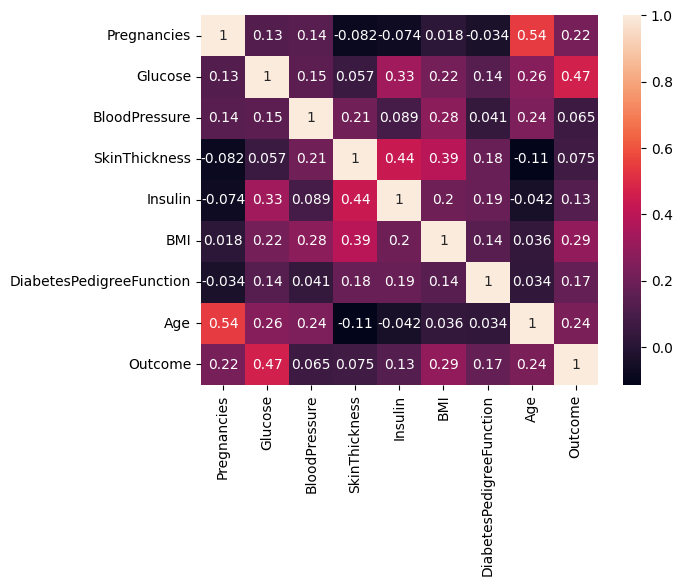

In [ ]:
XDB2 = XDB[['Pregnancies','Glucose', 'BloodPressure','SkinThickness','Insulin', 'BMI','DiabetesPedigreeFunction','Age', 'Outcome']]
sns.heatmap(XDB2.corr(), annot = True)

### **5.2. Implementación del modelo**

In [ ]:
np.random.seed(42)     # Permite generar los mismos valores aleatorios para todos
NC = 5                 #Número de clusters
mkm = KMeans (n_clusters = NC, random_state = 42)
mkm.fit(XD, yd)        #El modelo busca la mejor relación entre la entrada y la salida

# Obtener las características promedio de cada grupo
Tabla = pd.DataFrame(mkm.cluster_centers_, columns = XD.columns)
display(Tabla)

#Para saber los porcentajes de presencia o no de Diabetes por segmento
ydp = mkm.labels_       # Indica en qué clúster queda clasificado cada dato --> Pronóstico del modelo
NDc = np.bincount(ydp)  # Número de datos por clúster
print("El número de datos por clúster es: ", NDc)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,4.250000,149.615385,74.038462,30.865385,291.480769,35.575000,0.558635,33.903846
1,4.403646,119.096354,67.372396,11.932292,0.562500,30.954167,0.422201,35.583333
2,2.638418,101.954802,68.841808,26.853107,77.841808,31.096610,0.469458,27.836158
3,3.111111,165.833333,73.444444,35.666667,548.833333,36.961111,0.660667,34.555556
4,3.781022,133.598540,71.861314,30.583942,162.452555,34.048175,0.556504,33.233577


El número de datos por clúster es:  [ 52 384 177  18 137]


###**5.3. Porcentaje de Presencia de Diabetes**

In [ ]:
XDB2['Cluster'] = ydp
display(XDB2)

#Determinar el número de personas que presentan y que no presentan diabetes por clúster
NDiab = XDB2.groupby('Cluster').agg({"Outcome":lambda x: (x == 1).sum()})
NSinDiab = XDB2.groupby('Cluster').agg({"Outcome":lambda x: (x == 0).sum()})
df2 = pd.DataFrame(np.column_stack((NDiab, NSinDiab)), columns = ['Casos Positivos', 'Casos Negativos'])
display(df2)

# Calcular los porcentajes de diabetes y no diabetes por clúster
NDiab2 = NDiab/(NDiab+NSinDiab); NSinDiab2 = NSinDiab/(NDiab+NSinDiab)
df3 = pd.DataFrame(np.column_stack((NDiab2, NSinDiab2)), columns = ['Casos Positivos', 'Casos Negativos'])
display(df3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
0,6,148,72,35,0,33.6,0.627,50,1,1
1,1,85,66,29,0,26.6,0.351,31,0,1
2,8,183,64,0,0,23.3,0.672,32,1,1
3,1,89,66,23,94,28.1,0.167,21,0,2
4,0,137,40,35,168,43.1,2.288,33,1,4
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,4
764,2,122,70,27,0,36.8,0.340,27,0,1
765,5,121,72,23,112,26.2,0.245,30,0,2
766,1,126,60,0,0,30.1,0.349,47,1,1


,Casos Positivos,Casos Negativos
0,26,26
1,140,244
2,23,154
3,12,6
4,67,70


,Casos Positivos,Casos Negativos
0,0.500000,0.500000
1,0.364583,0.635417
2,0.129944,0.870056
3,0.666667,0.333333
4,0.489051,0.510949


###**5.4. Gráfica de los clusters**
Se procede con la gráfica de los clústers utilizando la variables con mayor correlación, que son embarazo y edad.

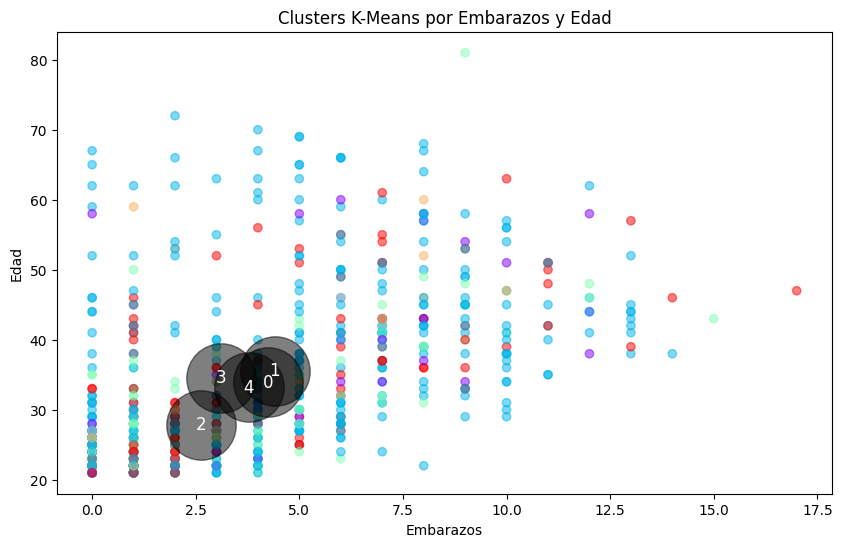

In [ ]:
centers = mkm.cluster_centers_  # centroides
embarazos = np.array(XD.iloc[:, 0])  # columna Embarazos
edad = np.array(XD.iloc[:, 7])       # columna Edad

plt.figure(figsize=(10,6))
plt.scatter(embarazos, edad, c=mkm.labels_, cmap='rainbow', alpha=0.5)  # puntos del dataset
plt.scatter(centers[:, 0], centers[:, 7], c="black", s=2500, alpha=0.5)  # centroides

plt.xlabel("Embarazos")
plt.ylabel("Edad")
plt.title("Clusters K-Means por Embarazos y Edad")

# Añadir números a los centroides
for i, center in enumerate(centers):
    plt.text(center[0], center[7], str(i), color='white', fontsize=12, ha='center', va='center')

plt.show()

###**Análisis de Resultados**

* **Correlación/Heatmap**

Las variables que presentan una mayor correlación son **Pregnancies** y **Age** (54%), lo que indica que cuando una de estas variables aumenta, la otra tiende a incrementarse también. En otras palabras, las personas con mayor edad tienden a haber tenido un mayor número de embarazos.

Otra correlación de relevancia es la que se presenta entre **Insulin** y **SkinThickness** (39%), lo que sugiere que a medida que aumenta el nivel de insulina de los pacientes, también tiende a incrementarse ligeramente el grosor de la piel.

Por otro lado, la variable que tiene una mayor correlación con la variable de salida **Outcome** es **Glucose**, con una correlación cercana al 47%. Así, los niveles de glucosa en sangre son uno de los factores más determinantes para identificar la presencia de diabetes en los pacientes.



* **Datos por clusters**

Se identificaron cinco grupos de pacientes con características simlares considerando las variables de salud que se disponían en el dataset.

El **clúster 1** es el grupo con mayor número de pacientes, con un total de *384* individuos, seguido del **clúster 2**, que cuenta con *177* pacientes y el **clúster 4** con *137*. Por otro lado, los **clústeres 0 y 3** son los grupos con menor cantidad de observaciones, con *52* y *18* pacientes respectivamente.

En cuanto a las características promedio de los grupos, se observa que el **clúster 3** presenta los niveles de *glucosa* más altos (165.83), el mayor nivel promedio de *insulina* (548.83) y uno de los valores más altos de IMC (36.96), lo que sugiere que este grupo concentra pacientes con mayor riesgo de desarrollar diabetes.

Por otro lado, el **clúster 2** presenta los niveles de *glucosa* más bajos (101.95) y valores relativamente moderados en *IMC* y *edad*, lo que indica que estos pacientes tienen menor riesgo relativo de desarrollar la enfremedad.

Asimismo, el **clúster 1**, apesar de ser el más grande, presenta niveles intermedios de *glucosa* (119.09) y *IMC* (30.95), presentando riesgo moderado.

Los **clusteres 0** y **4** tienen valores relativamente elevados de glucosa (149.61 y 133.59 respectivamente) y BMI superiores a 34, lo que podría indicar una mayor predisposición a la enfermedad en comparación con los grupos de menor glucosa, ya que es la variable más importante.


* **Porcentajes**

Se observa que el **clúster 3** tiene la *mayor probablidad* de diabetes, con un 66,67% de casos positivos, lo que coincide con las características promedio del grupo.

El **clúster 0 y 4** presentan una *probabilidad intermedia* de diabetes, con cerca de un 50% de casos positivos.

En contraste, el **clúster 1**, a pesar de ser el grupo más numéroso, y el **clúster 2** presentan los *menores porcentajes* de diabetes, con valores de 36,46% y 12,99% respectivamente. Para **clúster 2**, esto coincide con el bajo nivel de glucosa.

* **Scatter Plot**

A partir del gráfico de dispersión entre las variables **Embarazos** y **Edad**, se puede observar la distribución de los pacientes dentro de los diferentes clusters.

En primer lugar, se evidencia que los puntos presentan una alta dispersión, probablemente debido a que los pacentes tienen características variadas, algo esperado en datos de salud

Además, algunos clusters tienden a concentrarse en determinadas zonas del gráfico. Por ejemplo, se identifican grupos de pacientes que se ubican principalmente en rangos de edad entre los 25 y 40 años y con entre 2 y 6 embarazos, loque corresponde a uno de los segmentos más representativos dentro del conjunto de datos.

Así, el scatter plot permite visualizar cómo el modelo agrupa a los pacientes en diferentes segmentos según sus características, evidenciando que existen perfiles diferenciados de pacientes.

###**5.4. Ingreso de Nuevo Paciente**
De acuerdo con las variables que definen el siguiente paciente, se indican los resultados que arroja el modelo frente a la presencia de diabetes: XDp=[2,85,65,29,94,39.6,0.93,27]

In [ ]:
KM_XDp = np.array([2,85,39.6,27])
ydp = mkm.predict(KM_XDp.reshape(1,-1))   # Reshape: ajustar la forma del arreglo para la predicción
NCl = ydp[0]                              # Indica el clúster al que pertenece el paciente

print("La persona pertenece al clúster: ", ydp)
print("\nEl procentaje de tener diabetes para la nueva persona es: ", NDiab2.iloc[NCl])
print("\nEl procentaje de no tener diabetes para la nueva persona es: ", NSinDiab2.iloc[NCl])

La persona pertenece al clúster:  [3]
El procentaje de tener diabetes para la nueva persona es:  Outcome    0.075949
Name: 3, dtype: float64
El procentaje de no tener diabetes para la nueva persona es:  Outcome    0.924051
Name: 3, dtype: float64


# **Análisis Final de Resultados**
Un análisis escrito que concluya cuál modelo recomendaría para este problema y por qué, sustentando su decisión en las métricas obtenidas y en criterios de negocio o interpretación.

A partir de los resultados obtenidos en los diferentes modelos, es posible comprarar considerando tanto las métricas de desempeño como criterios de interpretación y utilidad para la toma de decisiones

En primer lugar, el modelo de **Naive Bayes** mostró un desempeño adecuado para la clasificación de los pacientes. Es un modelo simple y eficiente, que funciona bien en conjuntos de datos relativamente pequeños. Sin embargo, su principal limitación radica en la suposición de independencia entre las variables, lo cual puede no cumplirse del todo en datos médicos, donde las variables pueden estar relacionadas entre sí.

Por otra parte, el **Árbol de Decisión** presenta una ventaja importante para su interpretación al generar reglas claras y que se entiendne fácilmente, lo que es importante para contextos de salud al momento de la toma de decisiones y de comunicar los resultados

Finalmente, el **Clustering K-Means** permitió explorar patrones y agrupaciones naturales en los datos, pero no está diseñado específicamente para realizar predicciones de diagnóstico, por lo que su utilidad en este caso es principalmente exploratoria y complementaria a los modelos de clasificación.

Teniendo todo esto en cuenta, se consideran también las métricas obtenidas del **Arbol de Decisión**, donde obtuvo un porcentaje de **Especificidad** del *91.8%* y una **Exactitud** del *79.1%*, teniendo mayor desempeño que el modelo Naive Bayes.


Es importante mencionar también que se obtuvo el mismo resultado para el nuevo paciente, demostrando que los modelos no se contradecían sino que cada uno aporta perspectivas complementarias sobre los datos que se presentan. Sin mebargo, el **Árbol de Decisión** representa la alternativa más adecuada para este problema, al equilibrar desempeño al momento de predecir y la fácilidad para su interpretación y aplicación en un contexto real de salud.